# Risk Metrics Explained

This notebook builds intuition for the functions in `risk_metrics.py`.

**Sections**
1. Setup
2. Portfolio Return Distribution
3. Value at Risk (VaR)
   - 3.1 Historical simulation
   - 3.2 Parametric (variance-covariance)
   - 3.3 Historical vs parametric comparison
4. Conditional VaR (CVaR / Expected Shortfall)
5. Component VaR — Euler decomposition
6. Kupiec Proportion of Failures (POF) test

## 1. Setup

In [1]:
from utils import setup_repo_root

repo_root = setup_repo_root()
print("Working directory:", repo_root)

Working directory: /home/martin/python/risk-assessment


In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2, norm

from data_loader import clean_prices, load_positions, load_prices
from risk_metrics import (
    compute_component_var,
    compute_cvar_historical,
    compute_cvar_parametric,
    compute_var_historical,
    compute_var_parametric,
    kupiec_pof_test,
)

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 4)})
pd.set_option("display.float_format", "{:.6f}".format)

In [4]:
# Load positions and compute daily portfolio returns
positions = load_positions()
prices_raw = load_prices()
prices_clean = clean_prices(prices_raw)

prices_wide = (
    prices_clean
    .pivot(index="date", columns="instrument_id", values="price")
    .sort_index()
)
returns = prices_wide.pct_change().dropna(how="all")

weights = positions.set_index("instrument_id")["weight"]
common = returns.columns.intersection(weights.index)
port_returns = returns[common].dot(weights[common])

print(f"Portfolio return series: {len(port_returns)} days")
print(f"  {port_returns.index.min().date()} → {port_returns.index.max().date()}")
print(f"  mean={port_returns.mean():.4%}  std={port_returns.std():.4%}")

Portfolio return series: 252 days
  2025-04-01 → 2026-03-18
  mean=-0.0202%  std=0.6250%


## 2. Portfolio Return Distribution

All risk metrics operate on this return series.
A quick look at its shape tells us how fat the tails are relative to a
normal distribution — which matters for the historical vs parametric
comparison in Section 3.

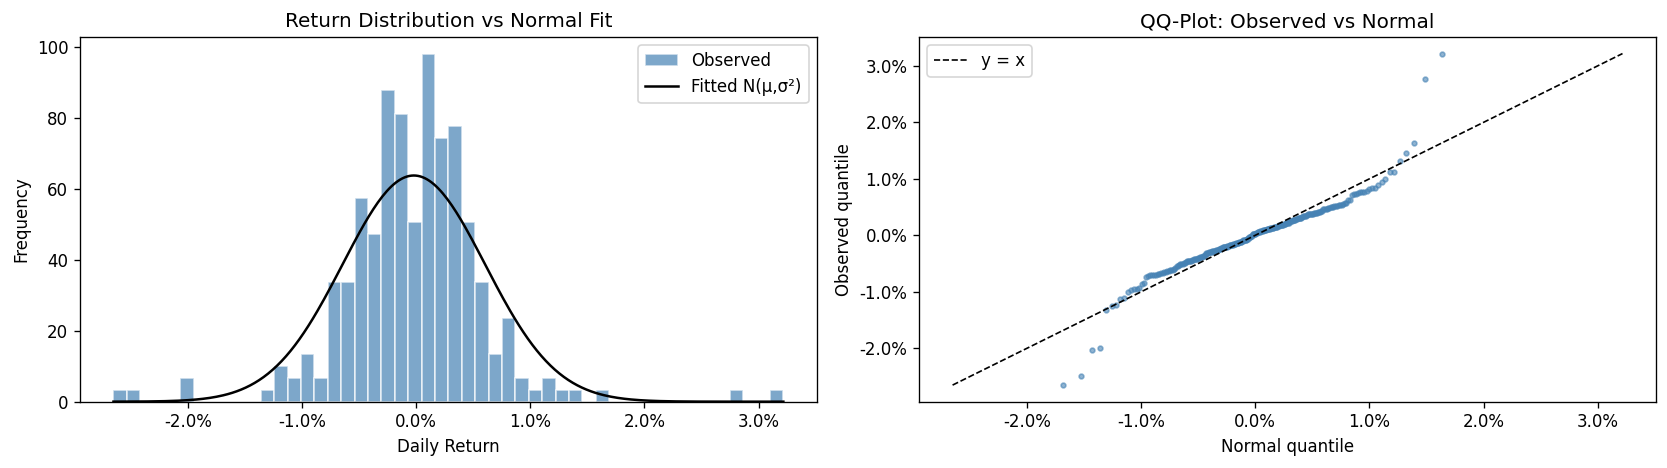

Skewness:        0.185  (0 = symmetric)
Excess kurtosis: 5.936  (0 = normal tails, >0 = fatter tails)


In [ ]:
mu = port_returns.mean()
sigma = port_returns.std()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram + fitted normal
ax = axes[0]
port_returns.plot.hist(ax=ax, bins=50, density=True, color="steelblue",
                       edgecolor="white", alpha=0.7, label="Observed")
x = np.linspace(port_returns.min(), port_returns.max(), 300)
ax.plot(x, norm.pdf(x, mu, sigma), color="black", linewidth=1.5, label="Fitted N(μ,σ²)")
ax.set_title("Return Distribution vs Normal Fit")
ax.set_xlabel("Daily Return")
ax.legend()
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))

# QQ-plot to visualise tail behaviour
ax2 = axes[1]
sorted_obs = np.sort(port_returns)
n = len(sorted_obs)
theoretical = norm.ppf(np.arange(1, n + 1) / (n + 1), mu, sigma)
ax2.scatter(theoretical, sorted_obs, s=8, color="steelblue", alpha=0.6)
lims = [min(theoretical.min(), sorted_obs.min()), max(theoretical.max(), sorted_obs.max())]
ax2.plot(lims, lims, color="black", linewidth=1, linestyle="--", label="y = x")
ax2.set_title("QQ-Plot: Observed vs Normal")
ax2.set_xlabel("Normal quantile")
ax2.set_ylabel("Observed quantile")
ax2.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Skewness:        {port_returns.skew():.3f}  (0 = symmetric)")
print(f"Excess kurtosis: {port_returns.kurt():.3f}  (0 = normal tails, >0 = fatter tails)")

## 3. Value at Risk (VaR)

VaR answers: *"What is the maximum loss I expect to see on all but the worst α% of days?"*

At **99% confidence** the VaR is the loss threshold that is exceeded on only 1% of trading days — roughly 2–3 times per year for a 250-day series.

### 3.1 Historical simulation

**Implementation:**
```python
VaR = -percentile(returns, 1)    # for 99% confidence
```

Step-by-step:
1. Sort all daily returns from worst to best.
2. Find the return at the 1st percentile (the bottom 1% of days).
3. Negate it — losses are positive by convention.

**Strength:** captures the true shape of the distribution including fat tails and skewness.  
**Weakness:** entirely backward-looking; a calm period underestimates future risk.

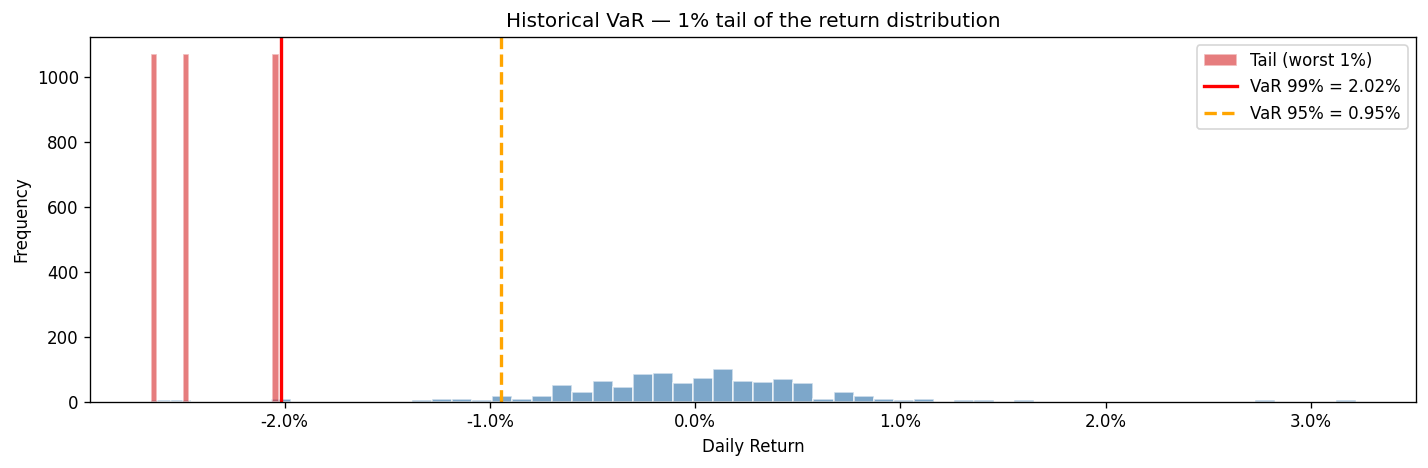

Historical VaR 95%: 0.9463%
Historical VaR 99%: 2.0153%

Interpretation: on 99% of days losses should not exceed 2.02% of portfolio value.
On a CHF 500M portfolio that is CHF 10,076,552.


In [ ]:
var_hist_99 = compute_var_historical(port_returns, confidence=0.99)
var_hist_95 = compute_var_historical(port_returns, confidence=0.95)

# --- visualise ---
fig, ax = plt.subplots(figsize=(12, 4))
port_returns.plot.hist(ax=ax, bins=60, density=True, color="steelblue",
                       edgecolor="white", alpha=0.7)

# shade the 1% tail
tail_returns = port_returns[port_returns < -var_hist_99]
ax.hist(tail_returns, bins=20, density=True, color="tab:red", alpha=0.6,
        edgecolor="white", label="Tail (worst 1%)")

ax.axvline(-var_hist_99, color="red", linewidth=2,
           label=f"VaR 99% = {var_hist_99:.2%}")
ax.axvline(-var_hist_95, color="orange", linewidth=2, linestyle="--",
           label=f"VaR 95% = {var_hist_95:.2%}")

ax.set_title("Historical VaR — 1% tail of the return distribution")
ax.set_xlabel("Daily Return")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Historical VaR 95%: {var_hist_95:.4%}")
print(f"Historical VaR 99%: {var_hist_99:.4%}")
print()
print("Interpretation: on 99% of days losses should not exceed",
      f"{var_hist_99:.2%} of portfolio value.")
print(f"On a CHF 500M portfolio that is CHF {var_hist_99 * 500e6:,.0f}.")

### 3.2 Parametric VaR (variance-covariance method)

**Formula:**
$$\text{VaR} = -\mu + \sigma \cdot z_{\alpha}$$

where $\mu$ is the sample mean, $\sigma$ the sample standard deviation, and $z_{\alpha} = \Phi^{-1}(\text{confidence})$ is the normal quantile (`norm.ppf(0.99) ≈ 2.326` for 99%).

**Strength:** fast, analytically tractable, scales to large portfolios.  
**Weakness:** the normality assumption underestimates tail risk when returns are fat-tailed or skewed (see QQ-plot above).

Formula:  VaR = -μ + σ · z
  μ      = -0.020203%
  σ      = 0.624953%
  z(99%) = 2.3263  [norm.ppf(0.99)]
  VaR    = --0.020203% + 0.624953% × 2.3263 = 1.4741%


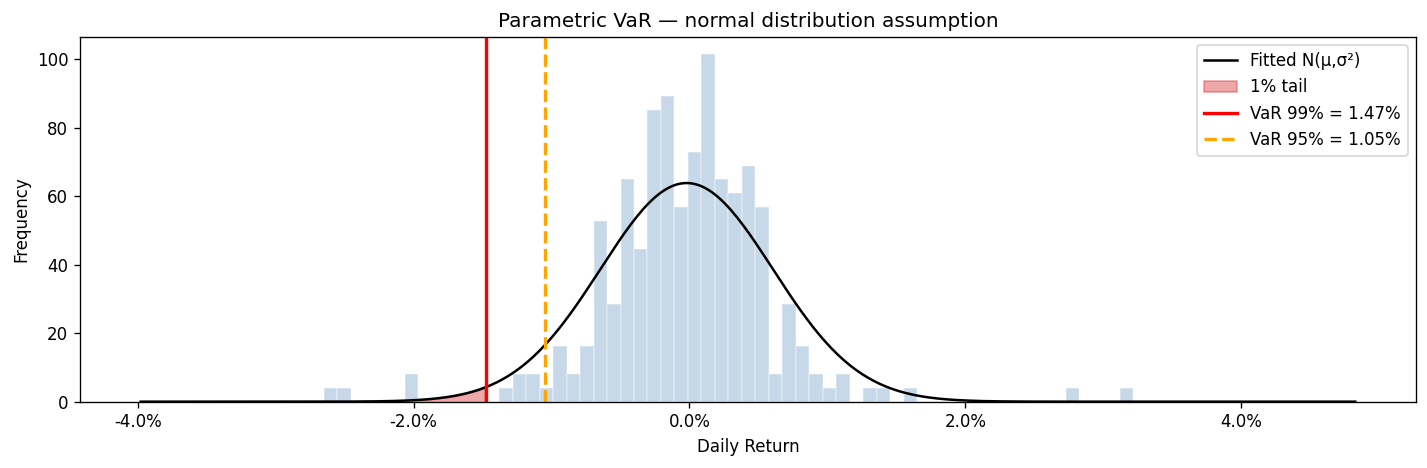

In [ ]:
var_param_99 = compute_var_parametric(port_returns, confidence=0.99)
var_param_95 = compute_var_parametric(port_returns, confidence=0.95)

# Show the formula components
z_99 = norm.ppf(0.99)
print("Formula:  VaR = -μ + σ · z")
print(f"  μ      = {mu:.6%}")
print(f"  σ      = {sigma:.6%}")
print(f"  z(99%) = {z_99:.4f}  [norm.ppf(0.99)]")
print(f"  VaR    = -{mu:.6%} + {sigma:.6%} × {z_99:.4f} = {var_param_99:.4%}")

# Visualise fitted normal with VaR threshold
fig, ax = plt.subplots(figsize=(12, 4))
x = np.linspace(port_returns.min() * 1.5, port_returns.max() * 1.5, 400)
pdf = norm.pdf(x, mu, sigma)

ax.plot(x, pdf, color="black", linewidth=1.5, label="Fitted N(μ,σ²)")

# shade 1% tail under fitted normal
x_tail = x[x <= -var_param_99]
ax.fill_between(x_tail, norm.pdf(x_tail, mu, sigma),
                color="tab:red", alpha=0.4, label="1% tail")

ax.axvline(-var_param_99, color="red", linewidth=2,
           label=f"VaR 99% = {var_param_99:.2%}")
ax.axvline(-var_param_95, color="orange", linewidth=2, linestyle="--",
           label=f"VaR 95% = {var_param_95:.2%}")

port_returns.plot.hist(ax=ax, bins=60, density=True, color="steelblue",
                       edgecolor="white", alpha=0.3)

ax.set_title("Parametric VaR — normal distribution assumption")
ax.set_xlabel("Daily Return")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
ax.legend()
plt.tight_layout()
plt.show()

### 3.3 Historical vs parametric comparison

When tails are fatter than normal, historical VaR > parametric VaR at high confidence levels.

,Historical,Parametric,Difference,CHF 500M — Historical,CHF 500M — Parametric
90%,0.6617%,0.8211%,-0.1595%,"CHF 3,308,267","CHF 4,105,566"
95%,0.9463%,1.0482%,-0.1018%,"CHF 4,731,645","CHF 5,240,801"
99%,2.0153%,1.4741%,0.5412%,"CHF 10,076,552","CHF 7,370,312"


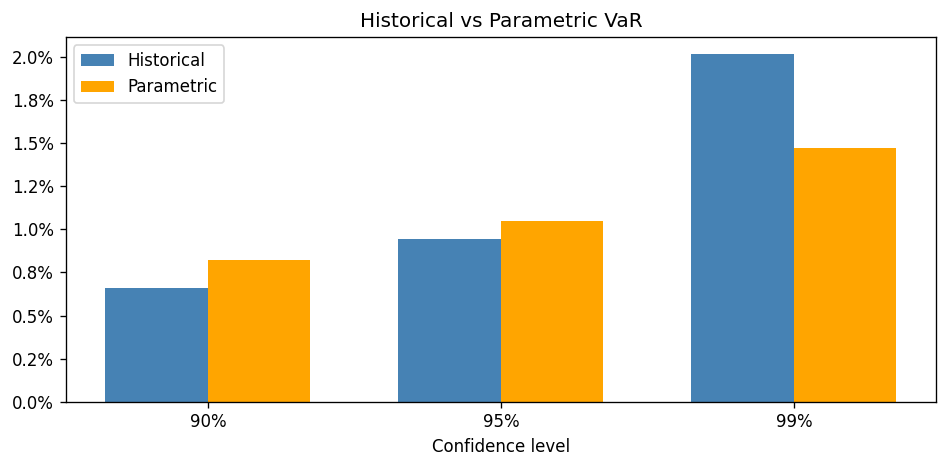

In [ ]:
comparison = pd.DataFrame(
    {
        "Historical": [
            compute_var_historical(port_returns, 0.90),
            compute_var_historical(port_returns, 0.95),
            compute_var_historical(port_returns, 0.99),
        ],
        "Parametric": [
            compute_var_parametric(port_returns, 0.90),
            compute_var_parametric(port_returns, 0.95),
            compute_var_parametric(port_returns, 0.99),
        ],
    },
    index=["90%", "95%", "99%"],
)
comparison["Difference"] = comparison["Historical"] - comparison["Parametric"]
comparison["CHF 500M — Historical"] = comparison["Historical"] * 500e6
comparison["CHF 500M — Parametric"] = comparison["Parametric"] * 500e6

display(comparison.style.format({
    "Historical": "{:.4%}",
    "Parametric": "{:.4%}",
    "Difference": "{:.4%}",
    "CHF 500M — Historical": "CHF {:,.0f}",
    "CHF 500M — Parametric": "CHF {:,.0f}",
}))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, comparison["Historical"], w, label="Historical", color="steelblue")
ax.bar(x + w/2, comparison["Parametric"], w, label="Parametric", color="orange")
ax.set_xticks(x)
ax.set_xticklabels(["90%", "95%", "99%"])
ax.set_xlabel("Confidence level")
ax.set_title("Historical vs Parametric VaR")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
ax.legend()
plt.tight_layout()
plt.show()

## 4. Conditional VaR (CVaR) — Expected Shortfall

VaR tells us *where* the tail begins but says nothing about *how bad* losses
in the tail are.  Two portfolios can have identical VaR yet very different
worst-case losses.

**CVaR** (also called Expected Shortfall, ES) answers: *"Given that we are
already in the worst 1% of days, what is the average loss?"*

$$\text{CVaR} = -\mathbb{E}[R \mid R < -\text{VaR}]$$

CVaR $\geq$ VaR always, and the gap reflects the severity of tail risk beyond
the VaR threshold.

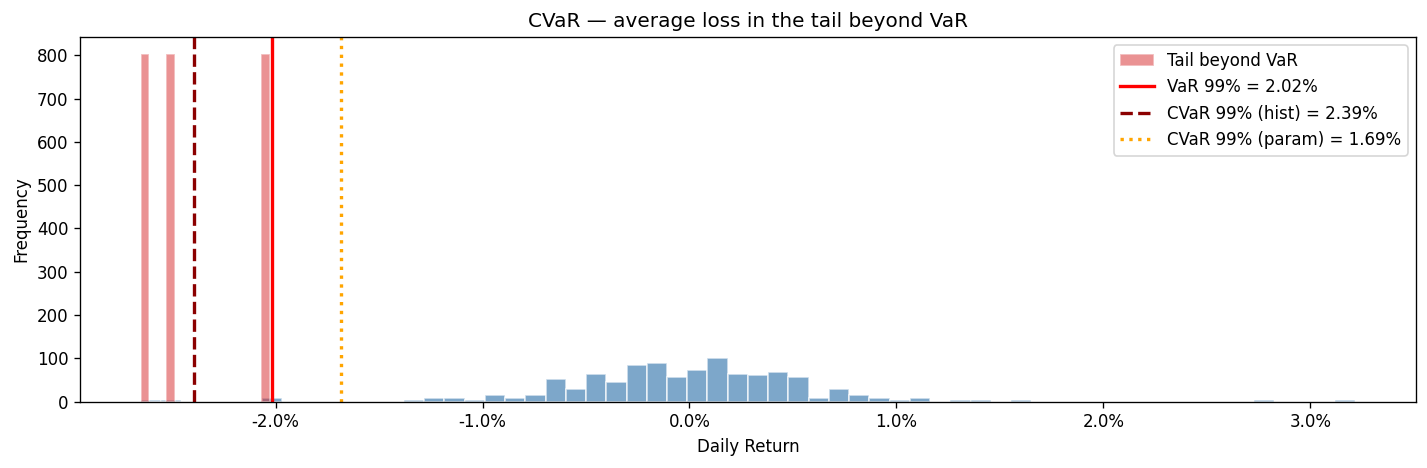

VaR  99% (historical):  2.0153%   ← loss threshold
CVaR 99% (historical):  2.3921%   ← average loss given we are in the tail
CVaR 99% (parametric):  1.6858%

CVaR/VaR ratio (hist):  1.19x
Tail observations used: 3 days


In [ ]:
cvar_hist_99  = compute_cvar_historical(port_returns, 0.99)
cvar_param_99 = compute_cvar_parametric(port_returns, 0.99)

tail_obs = port_returns[port_returns < -var_hist_99]

fig, ax = plt.subplots(figsize=(12, 4))
port_returns.plot.hist(ax=ax, bins=60, density=True, color="steelblue",
                       edgecolor="white", alpha=0.7)

# shade VaR tail
ax.hist(tail_obs, bins=15, density=True, color="tab:red", alpha=0.5,
        edgecolor="white", label="Tail beyond VaR")

ax.axvline(-var_hist_99, color="red", linewidth=2,
           label=f"VaR 99% = {var_hist_99:.2%}")
ax.axvline(-cvar_hist_99, color="darkred", linewidth=2, linestyle="--",
           label=f"CVaR 99% (hist) = {cvar_hist_99:.2%}")
ax.axvline(-cvar_param_99, color="orange", linewidth=2, linestyle=":",
           label=f"CVaR 99% (param) = {cvar_param_99:.2%}")

ax.set_title("CVaR — average loss in the tail beyond VaR")
ax.set_xlabel("Daily Return")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
ax.legend()
plt.tight_layout()
plt.show()

print(f"VaR  99% (historical):  {var_hist_99:.4%}   ← loss threshold")
print(f"CVaR 99% (historical):  {cvar_hist_99:.4%}   ← average loss given we are in the tail")
print(f"CVaR 99% (parametric):  {cvar_param_99:.4%}")
print()
print(f"CVaR/VaR ratio (hist):  {cvar_hist_99/var_hist_99:.2f}x")
print(f"Tail observations used: {len(tail_obs)} days")

### Parametric CVaR formula

For a normal distribution the tail expectation has a closed form:

$$\text{CVaR} = -\mu + \sigma \cdot \frac{\phi(z_{\alpha})}{\alpha}$$

where $\phi$ is the standard normal PDF and $\alpha = 1 - \text{confidence}$.

The ratio $\phi(z_{\alpha})/\alpha$ is called the **inverse Mills ratio** — it
measures how much probability density lies in the tail relative to its
probability mass.  For $\alpha = 0.01$: $\phi(-2.326)/0.01 \approx 2.67$, so
parametric CVaR is roughly 2.67 standard deviations from the mean.

In [18]:
alpha = 0.01
z_alpha = norm.ppf(alpha)
inv_mills = norm.pdf(z_alpha) / alpha

print("Parametric CVaR formula components:")
print(f"  α           = {alpha}")
print(f"  z_α         = norm.ppf({alpha}) = {z_alpha:.4f}")
print(f"  φ(z_α)      = norm.pdf({z_alpha:.4f}) = {norm.pdf(z_alpha):.6f}")
print(f"  φ(z_α)/α    = {inv_mills:.4f}   ← inverse Mills ratio")
print(f"  CVaR        = -{mu:.6%} + {sigma:.6%} × {inv_mills:.4f} = {cvar_param_99:.4%}")

Parametric CVaR formula components:
  α           = 0.01
  z_α         = norm.ppf(0.01) = -2.3263
  φ(z_α)      = norm.pdf(-2.3263) = 0.026652
  φ(z_α)/α    = 2.6652   ← inverse Mills ratio
  CVaR        = --0.020203% + 0.624953% × 2.6652 = 1.6858%


## 5. Component VaR — Euler Decomposition

Portfolio VaR is a single number for the whole portfolio.  Component VaR answers: *"How much does each position contribute to total VaR?"*

**Euler decomposition** exploits the fact that parametric VaR is a
**degree-1 homogeneous function** of the weights.  A function $f$ is
homogeneous of degree 1 if scaling all inputs by $\lambda > 0$ scales the
output by the same factor:

$$f(\lambda\,\mathbf{w}) = \lambda\,f(\mathbf{w})$$

Parametric VaR satisfies this because
$\text{VaR}(\lambda\mathbf{w}) = z_\alpha\sqrt{(\lambda\mathbf{w})^\top\Sigma(\lambda\mathbf{w})} = \lambda\,z_\alpha\sqrt{\mathbf{w}^\top\Sigma\mathbf{w}} = \lambda\,\text{VaR}(\mathbf{w})$.

By **Euler's theorem** for degree-1 homogeneous functions:

$$\text{VaR}_{\text{total}} = \sum_i w_i \cdot \frac{\partial \text{VaR}}{\partial w_i}$$

The partial derivative $\partial\text{VaR}/\partial w_i$ is the **marginal VaR** — the rate at which total VaR increases as we increase position $i$.

> Parametric VaR is **subadditive** — combining two portfolios *reduces* or
> at best preserves total VaR — so $\text{VaR}(\mathbf{w}+\mathbf{v}) \leq \text{VaR}(\mathbf{w})+\text{VaR}(\mathbf{v})$.
> This is the mathematical expression of **diversification benefit**.

**Formula:**
$$\text{Component VaR}_i = w_i \cdot \frac{(\Sigma\, \mathbf{w})_i}{\sigma_p} \cdot z_{\alpha}$$

where $\Sigma$ is the covariance matrix, $\mathbf{w}$ the weight vector, and $\sigma_p = \sqrt{\mathbf{w}^\top \Sigma\, \mathbf{w}}$ the portfolio volatility.

**Key property:** component VaRs sum exactly to total VaR — unlike stand-alone VaRs which ignore diversification.

In [19]:
weights_arr = positions.set_index("instrument_id").loc[common, "weight"].values
cov_matrix  = returns[common].cov().values

comp_var = compute_component_var(weights_arr, cov_matrix, confidence=0.99)

port_vol  = float(np.sqrt(weights_arr @ cov_matrix @ weights_arr))
total_var = port_vol * norm.ppf(0.99)

print(f"Portfolio volatility (daily): {port_vol:.4%}")
print(f"Total parametric VaR 99%:     {total_var:.4%}")
print(f"Sum of component VaRs:        {comp_var.sum():.4%}  ← must equal total VaR")
print(f"Difference:                   {abs(comp_var.sum() - total_var):.2e}  (rounding only)")

comp_df = (
    pd.DataFrame({"instrument_id": common, "component_var": comp_var})
    .merge(positions[["instrument_id", "weight", "sub_class"]], on="instrument_id")
    .assign(pct_of_total=lambda df: df["component_var"] / total_var)
    .sort_values("component_var", ascending=False)
    .reset_index(drop=True)
)
comp_df[["instrument_id", "sub_class", "weight", "component_var", "pct_of_total"]]

Portfolio volatility (daily): 0.6250%
Total parametric VaR 99%:     1.4539%
Sum of component VaRs:        1.4539%  ← must equal total VaR
Difference:                   3.47e-18  (rounding only)


,instrument_id,sub_class,weight,component_var,pct_of_total
0,NOVN,SWISS_EQUITY,0.055000,0.001970,0.135512
1,ROG,SWISS_EQUITY,0.050000,0.001954,0.134402
2,UBSG,SWISS_EQUITY,0.035000,0.001856,0.127663
3,ASML_NA,EUR_EQUITY,0.025000,0.001629,0.112060
4,NESN,SWISS_EQUITY,0.060000,0.001546,0.106338
5,ABBN,SWISS_EQUITY,0.030000,0.001298,0.089307
6,SIE_GR,EUR_EQUITY,0.025000,0.001136,0.078147
7,SAN_FP,EUR_EQUITY,0.030000,0.001124,0.077280
8,SREN,SWISS_EQUITY,0.020000,0.000932,0.064111
9,ALV_GR,EUR_EQUITY,0.020000,0.000857,0.058926


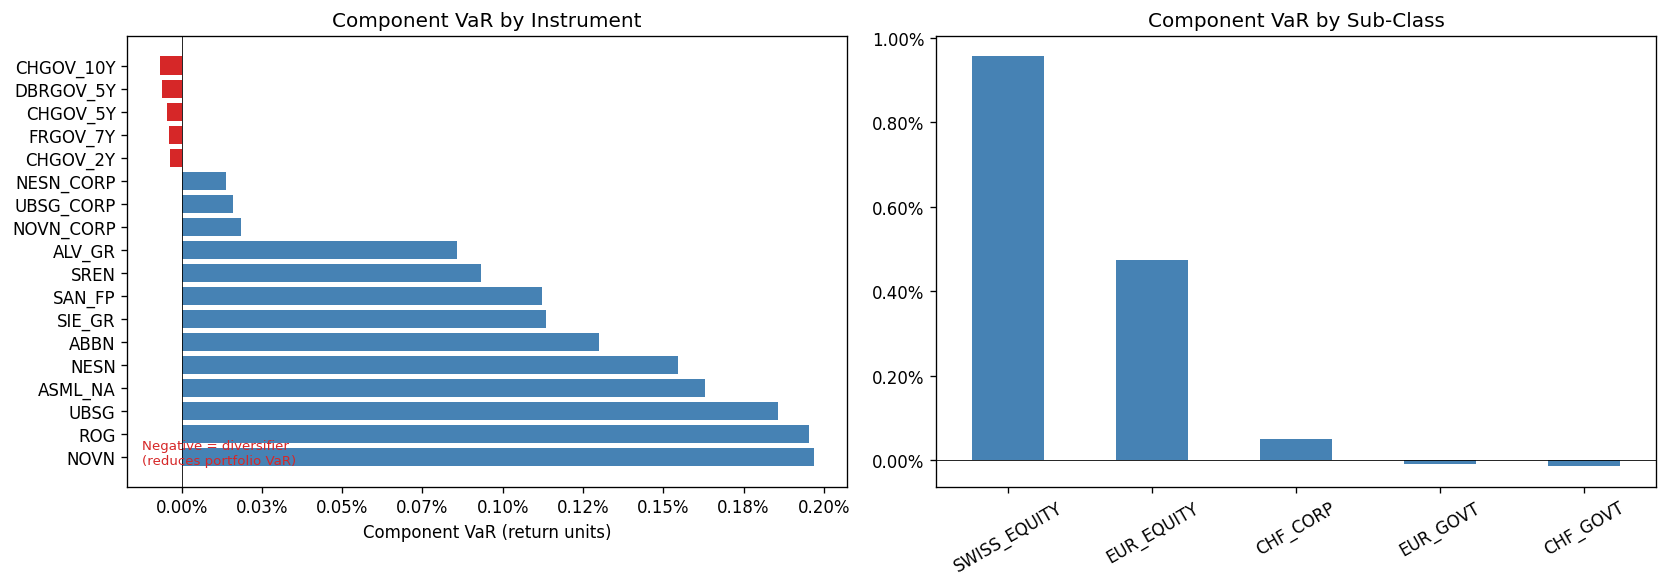

Positions with negative component VaR act as portfolio diversifiers:
  their returns tend to be high when the portfolio loses — they offset risk.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Component VaR by instrument
ax = axes[0]
colors = ["tab:red" if v < 0 else "steelblue" for v in comp_df["component_var"]]
ax.barh(comp_df["instrument_id"], comp_df["component_var"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_title("Component VaR by Instrument")
ax.set_xlabel("Component VaR (return units)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2%}"))
note = "Negative = diversifier\n(reduces portfolio VaR)"
ax.annotate(note, xy=(0.02, 0.05), xycoords="axes fraction", fontsize=8, color="tab:red")

# Component VaR grouped by sub_class
ax2 = axes[1]
sub_class_var = comp_df.groupby("sub_class")["component_var"].sum().sort_values(ascending=False)
sub_class_var.plot.bar(ax=ax2, color="steelblue", title="Component VaR by Sub-Class")
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_xlabel("")
ax2.tick_params(axis="x", rotation=30)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2%}"))

plt.tight_layout()
plt.show()

print("Positions with negative component VaR act as portfolio diversifiers:")
print("  their returns tend to be high when the portfolio loses — they offset risk.")

## 6. Kupiec Proportion of Failures (POF) Test

A VaR model must be validated.  The **Kupiec POF test** asks: *"Is the
observed number of VaR breaches statistically consistent with the model's
claimed confidence level?"*

**Setup:**  
- $T$ = number of trading days in the backtest  
- $N$ = observed number of days where the loss exceeded VaR  
- $p_0 = 1 - \text{confidence}$ = expected breach probability (e.g. 0.01 for 99% VaR)  
- $\hat{p} = N/T$ = observed breach rate  

**Likelihood ratio statistic:**
$$LR = 2\left[N\ln\frac{\hat{p}}{p_0} + (T-N)\ln\frac{1-\hat{p}}{1-p_0}\right]$$

Under $H_0$: $LR \sim \chi^2(1)$.  We reject $H_0$ if $LR > 3.84$
(5% significance level), meaning the model is mis-calibrated — either too
conservative (too few breaches) or too risky (too many).

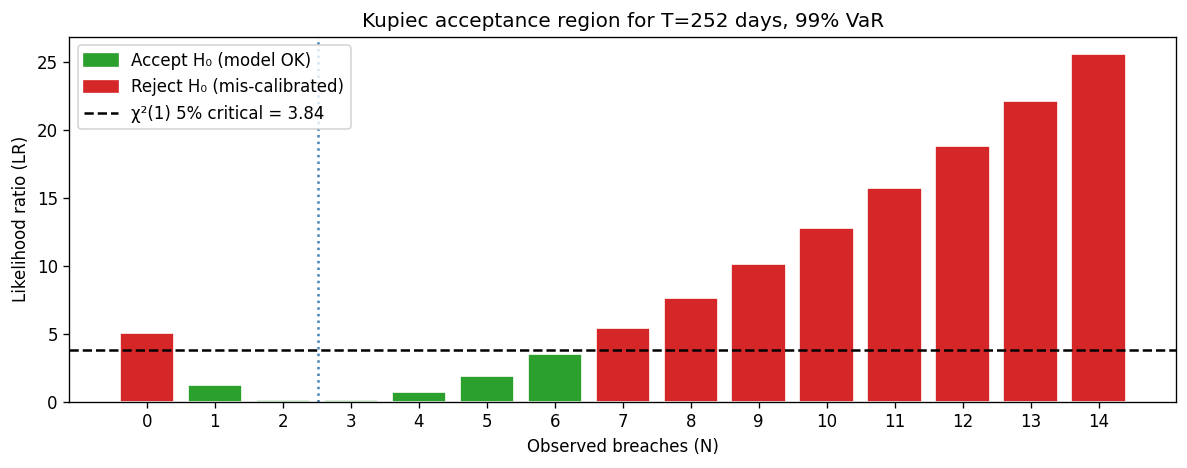

Expected breaches in 252 days at 99% confidence: 2.5
Acceptable range (H₀ not rejected at 5%): 1–6 breaches


In [21]:
# Show the acceptance region: how many breaches are acceptable for T=252 days?
T = 252
p0 = 0.01
critical_lr = chi2.ppf(0.95, df=1)  # 3.84

breach_range = np.arange(0, 15)
lr_values = []
for n in breach_range:
    result = kupiec_pof_test(T, int(n), confidence=0.99)
    lr_values.append(result["test_statistic"])

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["tab:green" if lr <= critical_lr else "tab:red" for lr in lr_values]
ax.bar(breach_range, lr_values, color=colors, edgecolor="white")
ax.axhline(critical_lr, color="black", linewidth=1.5, linestyle="--",
           label=f"χ²(1) 5% critical = {critical_lr:.2f}")

green_patch = mpatches.Patch(color="tab:green", label="Accept H₀ (model OK)")
red_patch   = mpatches.Patch(color="tab:red",   label="Reject H₀ (mis-calibrated)")
ax.legend(handles=[green_patch, red_patch,
                   ax.get_lines()[0]], loc="upper left")

expected = T * p0
ax.axvline(expected, color="steelblue", linewidth=1.5, linestyle=":",
           label=f"Expected breaches = {expected:.1f}")

ax.set_xlabel("Observed breaches (N)")
ax.set_ylabel("Likelihood ratio (LR)")
ax.set_title(f"Kupiec acceptance region for T={T} days, 99% VaR")
ax.set_xticks(breach_range)
plt.tight_layout()
plt.show()

print(f"Expected breaches in {T} days at 99% confidence: {expected:.1f}")
accept = [n for n, lr in zip(breach_range, lr_values) if lr <= critical_lr]
print(f"Acceptable range (H₀ not rejected at 5%): {accept[0]}–{accept[-1]} breaches")

In [23]:
# Run Kupiec on the actual portfolio using the full-sample historical VaR
# Note: for a proper backtest use rolling VaR (see run_analysis.py / backtest.py).
# Here we apply a fixed VaR to all days purely to demonstrate the test mechanics.

fixed_var = compute_var_historical(port_returns, 0.99)
n_breaches = int((port_returns < -fixed_var).sum())
n_obs = len(port_returns)

result = kupiec_pof_test(n_obs, n_breaches, confidence=0.99)

print("Kupiec POF test on full-sample portfolio")
print(f"  Observations:      {n_obs}")
print(f"  Expected breaches: {result['expected_breaches']:.1f}  (={n_obs} × {result['expected_rate']:.0%})")
print(f"  Observed breaches: {result['observed_breaches']}")
print(f"  Observed rate:     {result['observed_rate']:.2%}")
print(f"  LR statistic:      {result['test_statistic']:.4f}  (χ²(1) critical = {critical_lr:.2f})")
print(f"  p-value:           {result['p_value']:.4f}")
print(f"  Reject H₀:         {result['reject_h0']}")
print()
verdict = "FAIL — model is mis-calibrated" if result["reject_h0"] else "PASS — breach rate is consistent with 99% VaR"
print(f"Verdict: {verdict}")

Kupiec POF test on full-sample portfolio
  Observations:      252
  Expected breaches: 2.5  (=252 × 1%)
  Observed breaches: 3
  Observed rate:     1.19%
  LR statistic:      0.0870  (χ²(1) critical = 3.84)
  p-value:           0.7680
  Reject H₀:         False

Verdict: PASS — breach rate is consistent with 99% VaR
